이 노트북을 실행하는 데 필요한 라이브러리(표준 라이브러리 제외)
- torch
- numpy
- matplotlib

예제 실행 및 시각화를 위해 공통 라이브러리를 불러온다.
(공통 라이브러리에 대한 설명은 `code_reference/README.md` 파일을 참조)

In [1]:

# 코랩 환경 등 깃허브 전체를 clone해서 실습하는 경우가 아니라면 
# 공통 라이브러리를 불러오기 위해서 별도의 과정이 필요하므로 code_reference/README.md 파일을 확인하자.
import sys
sys.path.append('../../')

from code_reference import common
from code_reference import visualize as viz
# 시각화 결과를 파일에 저장하지 않음
viz.configure(save_grayscale=False)

# matplotlib에서 한글 폰트 사용 설정
common.set_korean_plot_env()

다음 셀은 결과 재현성을 보장하기 위해서 시드를 고정한다. 여기서 재현성은 '동일 컴퓨터, 동일 버전의 파이썬, 동일 버전의 파이토치' 환경에서 재현이 가능하다는 의미로, 독자의 결과는 저자의 결과와 달라질 수 있다는 점을 밝혀둔다.

In [2]:

import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# 4-1 데이터에서 시작하는 슬기로운 딥러닝 생활

본 노트북은 본문 4-1절의 코드 예제와 관련 내용을 다룬다. 주요 내용은 다음과 같다.
- 훈련, 검증, 평가 데이터셋의 분리와 검증 과정을 추가한 학습 함수
- 학습 곡선으로 과적합 확인
- 조기 종료와 참을성 한계
- 모델 파라미터의 저장과 복원(`state_dict()`, `load_state_dict()`, `torch.save()`, `torch.load()`)

3-3절에서 만든 회오리 데이터 분류 모델(모델 4)을 이어서 사용한다. 3-3절의 모델 제시문은 다음과 같다.

> **모델 4. 회오리 모양으로 분포한 데이터 분류 모델**
>
> 깃허브 저장소의 `data/ch3_spiral_data.csv` 파일에 담긴, 회오리 모양으로 분포한 900개의 2차원 좌표 데이터를 세 개의 클래스로 분류하는 모델을 만든다.

## 3-3절의 데이터와 모델 재현

- 본문 4-1절은 3-3절에서 만든 모델(교차 엔트로피 손실 함수 + ReLU 활성화 함수)을 이어서 사용한다.
- 노트북을 독립적으로 실행할 수 있도록 데이터를 다시 불러오고 같은 구조의 모델을 클래스로 정의한다.
- 본문 [코드 3-28]은 `nn.Sequential`로 모델을 만들지만, 여기서는 재학습할 때마다 같은 구조를 다시 만들기 편하도록 `SpiralMLPReLU` 클래스로 정의한다.

In [3]:
# 참고 - 3-3 절의 회오리 모양 분포 데이터 로드
import csv

# CSV 파일 저장 경로
data_path = '../../data/ch3_spiral_data.csv'

X_list, Y_list = [], []
with open(data_path, 'r') as f:
    # csv.DictReader 객체로 루프를 만들어 사용 (열 이름이 명시된 머리줄이 있는 경우)
    reader = csv.DictReader(f)              # 머리줄을 열 이름으로 자동 처리
    for row in reader:                      # row: 각 데이터 샘플의 딕셔너리
        X_list.append([float(row['x1']), float(row['x2'])])
        Y_list.append(int(row['label']))

# 리스트를 텐서로 변환
X = torch.tensor(X_list)                    # (900, 2) 형태의 텐서
Y = torch.tensor(Y_list)                    # (900,) 형태의 텐서

In [4]:
# 참고 - 3-3절의 교차 엔트로피 손실 + ReLU 활성화 함수 구조의 MLP 모델([코드 3-28])
#   클래스로 정의
import torch.nn as nn
from collections import OrderedDict

HIDDEN_DIM = 64                             # 은닉층 뉴런 수

class SpiralMLPReLU(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(OrderedDict([
            ('hidden_1', nn.Linear(2, HIDDEN_DIM)),
            ('activation_1', nn.ReLU()),
            ('hidden_2', nn.Linear(HIDDEN_DIM, HIDDEN_DIM)),
            ('activation_2', nn.ReLU()),
            ('output', nn.Linear(HIDDEN_DIM, 3)),
        ]))

    def forward(self, x):
        return self.net(x)

- 검증 과정을 추가한 학습 함수
    - 훈련 데이터셋뿐 아니라 검증 데이터셋도 학습 함수의 인자로 받는다.
    - 최적화 단계와 검증 단계를 한 학습 루프 안에서 번갈아 수행한다.
    - 검증은 파라미터 최적화와 무관한 평가 과정이므로 `model.eval()`로 평가 모드를 지정하고 `torch.no_grad()` 컨텍스트에서 계산한다.
    - 한 루프 안에서 두 모드를 오가므로 `model.train()` 호출도 학습 루프 안에 있어야 한다.
- 본문의 학습 로그 출력 부분(`# ...(이하 생략)...`)은 공통 라이브러리의 표준 학습 로거(`common.EpochLogger`)로 대신한다.

In [5]:
######################################################################################
# 코드 4-1 - 검증 과정을 추가한 학습 함수
######################################################################################

# 훈련 데이터셋(_train)뿐 아니라 검증 데이터셋(_valid)도 학습 함수에서 사용
def train(model, X_train, Y_train, X_valid, Y_valid, criterion, optimizer, epochs):
    # 표준 학습 로거 설정 
    log = common.EpochLogger(epochs, columns=('훈련 손실', '검증 손실'),
                             formats=('{:.4f}', '{:.4f}'))

    for epoch in range(1, epochs + 1):
        # 최적화 단계
        # 에포크마다 최적화와 검증을 반복하므로 학습 루프 내부에서 모드를 변경해야 함
        model.train()                                       # 학습 모드
        Y_train_pred = model(X_train)
        train_loss = criterion(Y_train_pred, Y_train)       # 훈련 손실 계산
        optimizer.zero_grad()
        train_loss.backward()                               # 훈련 손실로 역전파
        optimizer.step()
        # 검증 단계: 검증 데이터셋으로 현재까지 학습한 모델의 성능을 평가
        model.eval()                                        # 평가 모드
        with torch.no_grad():
            Y_valid_pred = model(X_valid)
            valid_loss = criterion(Y_valid_pred, Y_valid)   # 검증 손실 계산

        # 학습 로그 저장 및 출력
        log.row(epoch, train_loss.item(), valid_loss.item())
    return log

- 데이터셋을 6:2:2 비율로 훈련, 검증, 평가 데이터셋으로 나눈다.
    - 훈련 데이터셋(540개): 파라미터 최적화에 사용
    - 검증 데이터셋(180개): 학습 중 모델 성능 확인에 사용
    - 평가 데이터셋(180개): 학습이 모두 끝난 뒤 최종 성능 측정에 사용
- 데이터셋 구성과 학습 함수를 제외하면 3-3절과 같은 모델, 같은 하이퍼파라미터를 사용한다.

In [6]:
######################################################################################
# 코드 4-2 - 데이터셋을 훈련, 검증, 평가 데이터셋으로 나눈 후 검증 과정을 추가해 모델 학습
######################################################################################

import torch.optim as optim

# 데이터를 6:2:2 비율로 훈련, 검증, 평가 데이터 분리
train_size = int(len(Y) * 0.6)              # 훈련 데이터셋 크기: 540
valid_size = int(len(Y) * 0.2)              # 검증 데이터셋 크기: 180
test_size = len(Y) - train_size - valid_size    # 평가 데이터셋 크기: 180
X_train = X[:train_size]                            # 훈련 데이터 (입력)
Y_train = Y[:train_size]                            # 훈련 데이터 (정답)
X_valid = X[train_size:train_size + valid_size]    # 검증 데이터 (입력)
Y_valid = Y[train_size:train_size + valid_size]    # 검증 데이터 (정답)
X_test = X[train_size + valid_size:]               # 평가 데이터 (입력)
Y_test = Y[train_size + valid_size:]               # 평가 데이터 (정답)

# 모델 객체 생성: SpiralMLPReLU 클래스 사용([코드 3-29]와 같은 구조를 클래스로 정의해 사용)
model_relu = SpiralMLPReLU()

# 하이퍼파라미터 설정
LR = 0.001
EPOCHS = 10000

# 옵티마이저와 손실 함수
optimizer = optim.Adam(model_relu.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

# 모델 학습 - 학습 함수/데이터셋 구성/전체 에포크(10000) 이외는 3-3 절과 동일
log = train(model_relu, X_train, Y_train, X_valid, Y_valid, criterion, optimizer, EPOCHS)

     에포크    훈련 손실    검증 손실     시간
    1/10000       1.0980       1.0989     0:00


 1000/10000       0.0667       0.1703     0:01


 2000/10000       0.0322       0.1955     0:02


 3000/10000       0.0213       0.2324     0:03


 4000/10000       0.0163       0.2903     0:04


...

 6000/10000       0.0099       0.3413     0:06


 7000/10000       0.0072       0.3698     0:07


 8000/10000       0.0054       0.4017     0:08


 9000/10000       0.0041       0.4530     0:09


10000/10000       0.0034       0.5080     0:10


- 훈련 손실과 검증 손실을 한 그래프에 그려 두 손실의 변화를 비교한다.

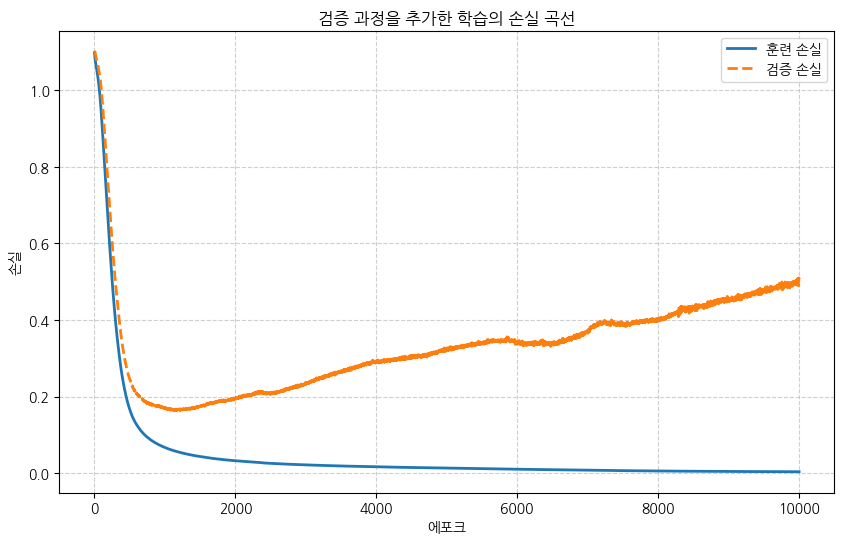

In [7]:
# 참고 - 훈련 손실과 검증 손실을 함께 나타낸 학습 곡선

log.plot(title='검증 과정을 추가한 학습의 손실 곡선', y_label='손실')

훈련 손실은 에포크가 늘어날수록 계속 줄어들지만, 검증 손실은 어느 시점부터 줄지 않고 오히려 늘어난다. 학습에 직접 사용한 데이터에서만 성능이 좋아진다는 뜻으로, 일반화 성능이 떨어지는 **과적합**의 증거다.

과적합이 언제부터 시작됐는지 확인하려면 검증 손실이 가장 낮았던 시점을 찾아야 한다. 이 시점에서 학습을 멈추는 방법이 **조기 종료**다.

- 조기 종료로 학습한 모델과 성능을 비교하기 위해 전체 에포크를 학습한 모델을 따로 보관한다.
    - 뒤에서 `model_relu`에 새 모델 객체를 할당하므로, 이름을 바꿔 두면 이전 모델이 그대로 남는다.

In [8]:
# 참고 - 조기 종료 방식으로 학습한 모델과 비교를 위해 모델 백업

model_full_epochs = model_relu

- 본문 [코드 4-3]은 최적화 단계와 검증 단계를 각각 `train_epoch()`, `validate()` 함수로 분리해 호출한다.
- 두 함수는 [코드 4-1]의 최적화 단계, 검증 단계와 같은 내용이며, 각각 훈련 손실과 검증 손실을 반환한다.

In [9]:
# 참고 - 1에포크 학습 함수와 검증 함수([코드 4-3] 실행에 필요)

# 1 에포크의 모델 파라미터를 최적화하는 학습 함수
def train_epoch(model, X_train, Y_train, criterion, optimizer):    
    model.train()                                       # 학습 모드
    Y_train_pred = model(X_train)
    train_loss = criterion(Y_train_pred, Y_train)       # 훈련 손실 계산
    optimizer.zero_grad()
    train_loss.backward()                               # 훈련 손실로 역전파
    optimizer.step()
    return train_loss.item()

# 모델 성능을 검증하는 평가 함수
def validate(model, X_valid, Y_valid, criterion):
    model.eval()                                        # 평가 모드
    with torch.no_grad():
        Y_valid_pred = model(X_valid)
        valid_loss = criterion(Y_valid_pred, Y_valid)   # 검증 손실 계산
    return valid_loss.item()

- 조기 종료를 적용한 학습 함수
    - 참을성 한계(`patience`) 인자를 추가로 받는다.
    - 검증 손실이 지금까지의 최솟값보다 작으면 최적 파라미터를 저장하고 참을성 카운터를 초기화한다.
    - 갱신되지 않으면 카운터를 늘리고, 참을성 한계를 넘으면 학습을 멈춘다.
    - 학습이 끝나면 최적 에포크의 파라미터로 모델을 복원한다.
- 최적 파라미터를 저장할 때 `copy.deepcopy()`로 깊은 복사를 하는 이유는 [코드 4-5] 다음 설명에서 다룬다.

In [10]:
######################################################################################
# 코드 4-3 - 조기 종료를 적용한 학습 함수
######################################################################################

# 깊은 복사(copy.deepcopy))를 위한 copy 모듈 임포트
import copy

# 조기 종료 방식을 적용하는 데 필요한 참을성 한계(patience) 인자 추가
def train_with_early_stopping(model,
                              X_train, Y_train, X_valid, Y_valid,
                              criterion, optimizer, epochs, patience):

    # 표준 학습 로거 생성
    log = common.EpochLogger(epochs, columns=('훈련 손실', '검증 손실'),
                             formats=('{:.4f}', '{:.4f}'))
    # ① 조기 종료 확인을 위한 변수 초기화
    best_valid_loss = float('inf')  # 지금까지의 최소 검증 손실: 충분히 큰 값으로 초기화
    best_model_params = None        # 검증 손실이 최소일 때의 파라미터를 저장할 딕셔너리
    patience_counter = 0            # 참을성 카운터
    best_epoch = 0                  # 최적 에포크: 검증 손실이 최소일 때의 에포크
    for epoch in range(1, epochs + 1):
        # ② 최적화 단계
        train_loss = train_epoch(model, X_train, Y_train, criterion, optimizer)

        # ③ 검증 단계
        valid_loss = validate(model, X_valid, Y_valid, criterion)

        # ④ 학습 로그 저장 및 출력
        log.row(epoch, train_loss, valid_loss)

        # ⑤ 조기 종료 판정: 현재 검증 손실과 지금까지의 최소 검증 손실을 비교
        if valid_loss < best_valid_loss:
            # 최소 검증 손실보다 작은 경우(현재가 최소 검증 손실)
            best_valid_loss = valid_loss                            # 최소 검증 손실 갱신
            best_model_params = copy.deepcopy(model.state_dict())   # 최소 검증 손실 시점의 파라미터 저장
            best_epoch = epoch                                      # 최소 손실 에포크 갱신
            patience_counter = 0                                    # 참을성 카운터 초기화
        else:
            # 최소 검증 손실이 갱신되지 않은 경우
            patience_counter += 1                                   # 참을성 카운터 1 증가
            if patience_counter >= patience:                        # 한계 초과 시 조기 종료                
                break

    # ⑥ 최소 검증 손실 시점(best_epoch)의 파라미터로 모델 복원
    print(f'최적({best_epoch} 에포크/검증 손실 {best_valid_loss:.4f}) 파라미터로 모델 복원')
    # 저장된 최소 검증 손실 시점 파라미터를 모델에 적용
    model.load_state_dict(best_model_params)
    return log

- 조기 종료 방식으로 모델을 다시 학습한다.
    - 재학습 전에 모델 객체와 옵티마이저를 새로 만들어야 이전 학습의 파라미터가 남지 않는다.
    - 참을성 한계는 100 에포크로 지정한다.

In [11]:
######################################################################################
# 코드 4-3 - 조기 종료를 적용한 학습 함수(계속)
######################################################################################

# 결과 재현을 위한 시드값 고정
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# 모델의 재학습을 위한 모델 객체 및 옵티마이저 재생성
# 새로 만들지 않으면 이전 학습에서의 파라미터가 그대로 남아 있어 재학습이 제대로 이루어지지 않음
model_relu = SpiralMLPReLU()
optimizer = optim.Adam(model_relu.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

# 모델 학습
PATIENCE = 100                                  # 참을성 한계: 100 에포크
log = train_with_early_stopping(
    model_relu, X_train, Y_train, X_valid, Y_valid,
    criterion, optimizer, EPOCHS, PATIENCE,
)

     에포크    훈련 손실    검증 손실     시간
    1/10000       1.0980       1.0989     0:00


 1000/10000       0.0667       0.1703     0:01


최적(1198 에포크/검증 손실 0.1638) 파라미터로 모델 복원


- 조기 종료로 학습한 모델의 학습 곡선을 확인한다.

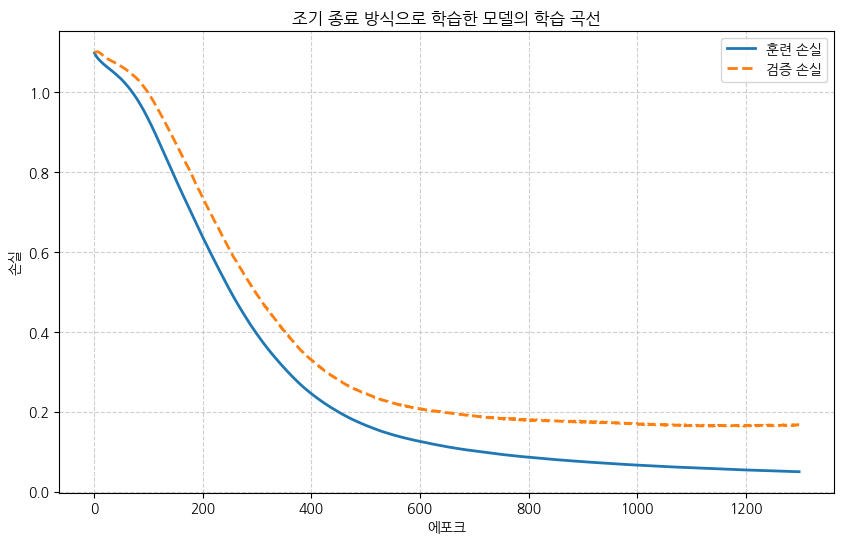

In [12]:
# 참고 - 조기 종료 방식에서의 학습 곡선
log.plot(title='조기 종료 방식으로 학습한 모델의 학습 곡선', y_label='손실')

- `state_dict()` 메서드
    - 모델의 파라미터를 계층 이름과 함께 담은 딕셔너리(`OrderedDict` 객체)를 반환한다.
    - 키는 `계층이름.weight`, `계층이름.bias` 형태로 구성된다.

In [13]:
######################################################################################
# 코드 4-4 - state_dict() 메서드가 반환하는 모델 파라미터 딕셔너리(OrderedDict 객체)
######################################################################################

model_params = model_relu.state_dict()
print(f'state_dict() 반환값 자료형: {type(model_params)}')
print(f'state_dict() 반환값의 키: {model_params.keys()}')

state_dict() 반환값 자료형: <class 'collections.OrderedDict'>
state_dict() 반환값의 키: odict_keys(['net.hidden_1.weight', 'net.hidden_1.bias', 'net.hidden_2.weight', 'net.hidden_2.bias', 'net.output.weight', 'net.output.bias'])


- `load_state_dict()` 메서드
    - 파라미터 딕셔너리에 저장된 값으로 모델을 복원한다.
    - 제자리 연산 메서드이므로 할당 연산이 필요 없다.
    - 저장한 모델과 복원할 모델의 계층 이름 구성이 같고, 같은 이름의 계층끼리 파라미터 텐서 형태도 같아야 한다.
    - 이 조건만 맞으면 다른 방식으로 정의한 모델로도 복원할 수 있다.

In [14]:
######################################################################################
# 코드 4-5 - 파라미터로 모델을 복원하는 load_state_dict() 메서드
######################################################################################

# model_1: 두 개의 선형 계층으로 구성된 MLP 모델
# model_2: model_1과 계층 이름과 계층별 파라미터 텐서의 형태가 동일한 모델
# model_3: model_1과 계층 이름은 같지만 계층별 파라미터 텐서의 형태가 다른 모델
model_1 = nn.Sequential(OrderedDict([
    ('layer1', nn.Linear(2, 3)), ('layer2', nn.Linear(3, 1))
]))
model_2 = nn.Sequential(OrderedDict([
    ('layer1', nn.Linear(2, 3)), ('layer2', nn.Linear(3, 1))
]))
model_3 = nn.Sequential(OrderedDict([
    ('layer1', nn.Linear(2, 4)), ('layer2', nn.Linear(4, 1))
]))

# model_1의 파라미터 저장
model_1_params = model_1.state_dict()

# load_state_dict() 메서드는 제자리 연산 메서드로 할당 연산이 필요 없음
model_1.load_state_dict(model_1_params)         # 동일 모델의 파라미터 복원 가능
model_2.load_state_dict(model_1_params)         # model_1의 파라미터로 model_2 복원 가능
# model_3.load_state_dict(model_1_params): RuntimeError 예외(파라미터 텐서 형태 불일치)

<All keys matched successfully>

`state_dict()`가 반환하는 값은 모델 파라미터를 참조하는 가변형 객체다. 다른 변수에 할당해 두어도 학습 등으로 파라미터 값이 바뀌면 변수에 담긴 값도 함께 바뀐다. [코드 4-3]에서 최적 파라미터를 보관할 때 단순 할당 대신 `copy.deepcopy()`로 깊은 복사를 한 이유가 여기에 있다.

- 모델 파라미터를 파일에 저장하고 불러오기
    - `torch.save()`: 파라미터 딕셔너리와 파일 경로를 인자로 지정해 파일에 저장
    - `torch.load()`: 파일 경로를 지정해 파라미터 딕셔너리로 불러옴
    - 파이토치 모델 파라미터 파일의 확장자로는 보통 `.pt`나 `.pth`를 사용한다.

In [15]:
######################################################################################
# 코드 4-6 - 모델 파라미터를 파일에 저장하고 불러오기
######################################################################################

# checkpoint_dir: 체크포인트 파일을 저장할 디렉토리 경로
checkpoint_dir = '../../checkpoint'
# torch.save() - 파라미터 딕셔너리를 파일에 저장
# 파라미터 딕셔너리와 파일 경로를 인자로 지정
torch.save(model_relu.state_dict(), f'{checkpoint_dir}/model_relu.pt')

# torch.load() - 파일 경로를 지정해 파라미터 딕셔너리로 불러옴
param_dict = torch.load(f'{checkpoint_dir}/model_relu.pt')
model_relu.load_state_dict(param_dict)          # 불러들인 파라미터로 모델 복원

<All keys matched successfully>

- 조기 종료로 학습한 모델과 전체 에포크를 학습한 모델의 성능을 비교한다.
    - 학습과 검증에 사용하지 않은 평가 데이터셋으로 분류 정확도를 계산한다.
    - 더 짧게 학습한 조기 종료 모델의 성능이 더 좋다면, 과적합을 피해 일반화 성능이 높아졌다는 뜻이다.

In [16]:
# 참고 - 조기 종료 모델과 전체 학습 모델의 평가 정확도 비교

# 분류 정확도를 계산하는 함수
def get_accuracy(model, X, Y):
    model.eval()
    with torch.no_grad():
        classes = model(X).argmax(dim=-1)
    return (classes == Y).float().mean().item() * 100.0

# 훈련과 검증에 사용하지 않은 평가 데이터로 정확도 계산
accuracy_early_stopping = get_accuracy(model_relu, X_test, Y_test)
accuracy_full = get_accuracy(model_full_epochs, X_test, Y_test)
print(f'조기 종료 모델의 평가 정확도: {accuracy_early_stopping:.2f}%')
print(f'전체 학습({EPOCHS} 에포크) 모델의 평가 정확도: {accuracy_full:.2f}%')

조기 종료 모델의 평가 정확도: 92.78%
전체 학습(10000 에포크) 모델의 평가 정확도: 92.22%


## 정리

- 데이터셋을 훈련, 검증, 평가 세 묶음으로 나누면 학습 도중 검증 손실로 과적합을 관찰할 수 있다.
- 훈련 손실은 계속 줄어드는데 검증 손실이 늘어나기 시작하면 과적합이 진행되고 있다는 신호다.
- 조기 종료는 검증 손실의 최솟값이 참을성 한계(`PATIENCE`) 동안 갱신되지 않으면 학습을 멈추고, 최적 시점의 파라미터로 모델을 복원하는 방식이다.
- 모델 파라미터는 `state_dict()`와 `load_state_dict()`로 메모리에서, `torch.save()`와 `torch.load()`로 파일에서 저장하고 복원한다.
- `state_dict()`의 반환값은 모델 파라미터를 참조하므로, 값을 보관하려면 `copy.deepcopy()`로 깊은 복사를 해야 한다.

> 학습 결과의 구체적인 수치는 실행 환경에 따라 본문과 조금씩 다를 수 있다.